In [1]:
from sentence_transformers import SentenceTransformer, InputExample, losses
from sentence_transformers.evaluation import InformationRetrievalEvaluator
from torch.utils.data import DataLoader
import pandas as pd
import numpy as np
import random, math
from sklearn.metrics.pairwise import cosine_similarity

c:\Users\s223128143\AppData\Local\miniconda3\envs\myenv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
hanoi = pd.read_csv("hanoi.csv")
qa_df = pd.read_csv("qa_dataset.csv")
# Build document corpus
def build_document(row):
    parts = [
        str(row['property_type_name']),
        f"quận {row['district_name']}",
        f"{row['bedroom_count']:.0f} phòng ngủ" if pd.notna(row['bedroom_count']) else "",
        f"diện tích {row['area']} mét vuông" if pd.notna(row['area']) else "",
        f"giá {row['Billion VND']:.2f} tỷ đồng",
    ]
    return " ".join(p for p in parts if p)

hanoi['document'] = hanoi.apply(build_document, axis=1)
docs = hanoi["document"].tolist()

# Build (query, passage) pairs for MNR loss
Use all 3 variants as anchors to triple the training size. 

In [3]:
def build_pairs(qa_df, docs, seed=42):
    random.seed(seed)
    pairs = []
    for i in range(len(docs)):
        for v in ["clean", "address_variant", "code_switched"]:
            q = qa_df[v].iloc[i]
            d = docs[i]
            if q.strip() and d.strip():
                pairs.append(InputExample(texts=[f"query: {q}", f"passage: {d}"]))
    random.shuffle(pairs)
    return pairs

In [4]:
i = 0
for v in ["clean", "address_variant", "code_switched"]:
    q = qa_df[v].iloc[i]
    d = docs[i]
    print(f"Variant: {v}")
    print(f"  query: {q}")
    print(f"  passage: {d}")
    print()

Variant: clean
  query: Nhà 4 phòng ngủ tại quận Bắc Từ Liêm, diện tích 37 mét vuông, giá dưới 7.95 tỷ đồng
  passage: Nhà quận Bắc Từ Liêm 4 phòng ngủ diện tích 37.0 mét vuông giá 7.45 tỷ đồng

Variant: address_variant
  query: Nhà 4 PN tại Q Bắc Từ Liêm, 37 mét vuông, giá dưới 7.95 tỷ
  passage: Nhà quận Bắc Từ Liêm 4 phòng ngủ diện tích 37.0 mét vuông giá 7.45 tỷ đồng

Variant: code_switched
  query: house 4 BR tại Bắc Từ Liêm, 37 mét vuông, giá dưới 7.95 B
  passage: Nhà quận Bắc Từ Liêm 4 phòng ngủ diện tích 37.0 mét vuông giá 7.45 tỷ đồng



In [ ]:
random.seed(42)
n_docs = len(docs)
idx = list(range(n_docs))
random.shuffle(idx)

split = int(0.7 * n_docs)   # 70/30
train_idx = idx[:split]
eval_idx  = idx[split:]

train_pairs = build_pairs(
    qa_df.iloc[train_idx].reset_index(drop=True),
    [docs[i] for i in train_idx],
)
eval_pairs = build_pairs(
    qa_df.iloc[eval_idx].reset_index(drop=True),
    [docs[i] for i in eval_idx],
)

print(f"Train docs: {len(train_idx)}  |  Eval docs: {len(eval_idx)}")
print(f"Train pairs: {len(train_pairs)}  |  Eval pairs: {len(eval_pairs)}") 

Train docs: 3500  |  Eval docs: 1500
Train pairs: 10500  |  Eval pairs: 4500


In [6]:
me5 = SentenceTransformer("intfloat/multilingual-e5-base")

In [7]:
eval_qa = qa_df.iloc[eval_idx].reset_index(drop=True)
eval_docs = [docs[i] for i in eval_idx]

# Fine tune on all queries for me5

In [8]:
train_dataloader = DataLoader(train_pairs, shuffle=True, batch_size=16)
train_loss = losses.MultipleNegativesRankingLoss(me5)
warmup_steps = math.ceil(len(train_dataloader) * 1 * 0.1) # 10% of total steps

In [9]:
me5.fit(
    train_objectives=[(train_dataloader, train_loss)],
    epochs=1,
    warmup_steps=warmup_steps,
    optimizer_params={"lr": 2e-5},
    weight_decay=0.01,
    output_path="me5_finetuned",
    save_best_model=True, 
    show_progress_bar=True,
)

Step,Training Loss
500,0.081800


# Fine tune on clean query for me5

In [10]:
clean_only_pairs = []
for i in range(len(train_idx)):
    q = qa_df.iloc[train_idx[i]]["clean"]
    d = docs[train_idx[i]]
    if q.strip() and d.strip():
        clean_only_pairs.append(InputExample(texts=[f"query: {q}", f"passage: {d}"]))

me5_clean = SentenceTransformer("intfloat/multilingual-e5-base")

train_loader_clean = DataLoader(clean_only_pairs, shuffle=True, batch_size=32)
loss_fn_clean = losses.MultipleNegativesRankingLoss(me5_clean)
warmup_steps_clean = math.ceil(len(train_loader_clean) * 1 * 0.1) # 10% of total steps

me5_clean.fit(
    train_objectives=[(train_loader_clean, loss_fn_clean)],
    epochs=1,
    warmup_steps=warmup_steps_clean,
    optimizer_params={"lr": 2e-5},
    weight_decay=0.01,
    output_path="me5-clean-only",
    show_progress_bar=True,
)

Step,Training Loss


# Fine tune on all queries for vietnamese-bi-encoder

# Evaluation

In [11]:
def compute_metrics(doc_embs, query_embs, k=10):
    sim = cosine_similarity(query_embs, doc_embs)
    n = len(query_embs)
    recall_at_1 = np.zeros(n)
    mrr_scores  = np.zeros(n)
    for i in range(n):
        ranked = np.argsort(sim[i])[::-1]
        recall_at_1[i] = 1.0 if ranked[0] == i else 0.0
        pos = np.where(ranked[:k] == i)[0]
        if len(pos) > 0:
            mrr_scores[i] = 1.0 / (pos[0] + 1)
    return recall_at_1, mrr_scores

In [12]:
me5_baseline = SentenceTransformer("intfloat/multilingual-e5-base")
rows = []
mrr_raw = {}
model_dict_comparison = {
    "ME5 baseline": me5_baseline,
    "ME5 clean-only fine-tune": me5_clean,
    "ME5 all-variant fine-tune": me5,
}
for name, model in model_dict_comparison.items():
    mrr_raw[name] = {}
    doc_embs = model.encode(
        [f"passage: {d}" for d in eval_docs],
        batch_size=32, normalize_embeddings=True,
    )
    for v in ["clean", "address_variant", "code_switched"]:
        q_embs = model.encode(
            [f"query: {q}" for q in eval_qa[v].tolist()],
            batch_size=32, normalize_embeddings=True,
        )
        r1, mrr = compute_metrics(doc_embs, q_embs)
        mrr_raw[name][v] = mrr
        rows.append({
            "Model": name,
            "Query Type": v,
            "Recall@1": round(r1.mean(), 4),
            "MRR@10":   round(mrr.mean(), 4),
        })

In [13]:
result = pd.DataFrame(rows)
result["Query Type"] = pd.Categorical(
    result["Query Type"],
    categories=["clean", "address_variant", "code_switched"],
    ordered=True,
)

pivot_table = result.sort_values(["Model", "Query Type"]).pivot_table(
    index="Model", columns="Query Type", values=["Recall@1", "MRR@10"]
).reindex(["clean", "address_variant", "code_switched"], axis=1, level=1)
display(pivot_table)

C:\Users\s223128143\AppData\Local\Temp\ipykernel_31272\3896483156.py:8: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_table = result.sort_values(["Model", "Query Type"]).pivot_table(


MRR@10                               Recall@1  \
Query Type                  clean address_variant code_switched    clean   
Model                                                                      
ME5 all-variant fine-tune  0.8722          0.8730        0.8716    0.774   
ME5 baseline               0.6706          0.6545        0.6553    0.548   
ME5 clean-only fine-tune   0.8649          0.8681        0.8610    0.762   

                                                         
Query Type                address_variant code_switched  
Model                                                    
ME5 all-variant fine-tune          0.7767         0.774  
ME5 baseline                       0.5167         0.518  
ME5 clean-only fine-tune           0.7667         0.756

# t-SNE embedding space visualization 

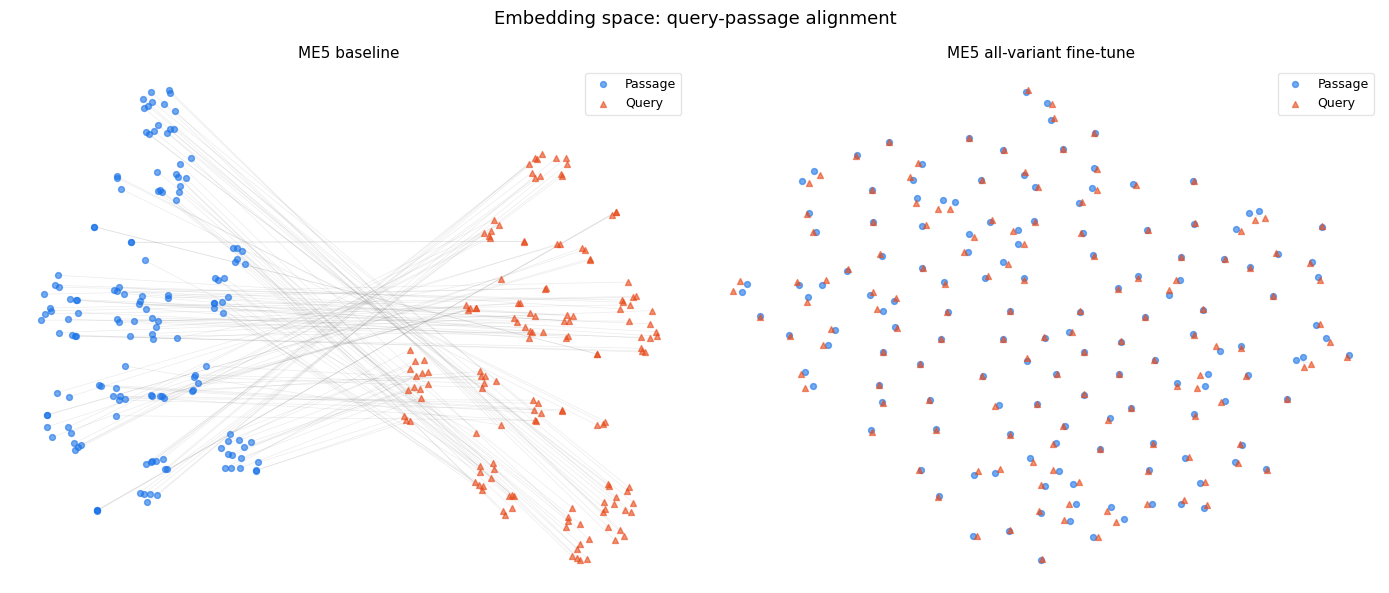

In [14]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

N_VIZ = 150
rng   = np.random.default_rng(42)
viz_idx = rng.choice(len(eval_idx), size=N_VIZ, replace=False)

viz_docs = [eval_docs[i] for i in viz_idx]
viz_qa   = eval_qa.iloc[viz_idx].reset_index(drop=True)

query_type = "clean"

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Embedding space: query-passage alignment", fontsize=13)
for ax, (label, model) in zip(axes, [
    ("ME5 baseline", me5_baseline),
    ("ME5 all-variant fine-tune", me5),
]):
    q_embs = model.encode(
        [f"query: {q}" for q in viz_qa[query_type].tolist()],
        normalize_embeddings=True,
    )
    d_embs = model.encode(
        [f"passage: {d}" for d in viz_docs],
        normalize_embeddings=True,
    )

    combined = np.vstack([q_embs, d_embs])
    tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
    coords = tsne.fit_transform(combined)

    q_coords = coords[:N_VIZ]
    d_coords = coords[N_VIZ:]

    # Draw thin lines connecting each query to its matching passage
    for i in range(N_VIZ):
        ax.plot([q_coords[i, 0], d_coords[i, 0]],
                [q_coords[i, 1], d_coords[i, 1]],
                color="gray", alpha=0.15, linewidth=0.5, zorder=1)

    ax.scatter(d_coords[:, 0], d_coords[:, 1],
               c="#1a73e8", s=18, alpha=0.6, label="Passage", zorder=2)
    ax.scatter(q_coords[:, 0], q_coords[:, 1],
               c="#e84a1a", s=18, alpha=0.6, marker="^", label="Query", zorder=3)

    ax.set_title(label, fontsize=11)
    ax.legend(fontsize=9, framealpha=0.5)
    ax.axis("off")

plt.tight_layout()
plt.savefig('tsne_plot.png')
plt.show()

# Qualitative error analysis 

In [21]:
def encode(model, texts, prefix):
    return model.encode([f"{prefix}: {t}" for t in texts], batch_size=32, normalize_embeddings=True)

def top1(q_embs, d_embs):
    return np.argmax(cosine_similarity(q_embs, d_embs), axis=1)

def print_cases(label, cases, n=3):
    print(f"\n─── {n} {label} ───")
    for i, base_pred, ft_pred in cases[:n]:
        print(f"\n  Query:        {eval_qa['code_switched'].iloc[i]}")
        print(f"  Ground truth: {eval_docs[i]}")
        print(f"  Baseline got: {eval_docs[base_pred]}")
        print(f"  Fine-tune got:{eval_docs[ft_pred]}")

# Encode
cs_queries = eval_qa["code_switched"].tolist()
base_top1 = top1(encode(me5_baseline, cs_queries, "query"), encode(me5_baseline, eval_docs, "passage"))
ft_top1   = top1(encode(me5, cs_queries, "query"), encode(me5, eval_docs, "passage"))

# Categorise
n = len(eval_docs)
wins = [(i, base_top1[i], ft_top1[i]) for i in range(n) if base_top1[i] != i and ft_top1[i] == i]
both_wrong= [(i, base_top1[i], ft_top1[i]) for i in range(n) if base_top1[i] != i and ft_top1[i] != i]

print_cases("examples where fine-tuning gets the correct retrieval and zero shot don't", wins)
print_cases("cases where both models fail to get correct retrieval", both_wrong)


─── 3 examples where fine-tuning gets the correct retrieval and zero shot don't ───

  Query:        Need bán apartment tại Nam Từ Liêm, 2 BR, 72 mét vuông, giá dưới 6.96 B.
  Ground truth: Căn hộ chung cư quận Nam Từ Liêm 2 phòng ngủ diện tích 72.0 mét vuông giá 6.46 tỷ đồng
  Baseline got: Căn hộ chung cư quận Nam Từ Liêm 2 phòng ngủ diện tích 72.0 mét vuông giá 6.00 tỷ đồng
  Fine-tune got:Căn hộ chung cư quận Nam Từ Liêm 2 phòng ngủ diện tích 72.0 mét vuông giá 6.46 tỷ đồng

  Query:        house tại Hà Đông, 1 BR, 52 mét vuông, giá dưới 11 B.
  Ground truth: Nhà quận Hà Đông 1 phòng ngủ diện tích 52.0 mét vuông giá 10.50 tỷ đồng
  Baseline got: Nhà quận Hà Đông 4 phòng ngủ diện tích 52.7 mét vuông giá 19.00 tỷ đồng
  Fine-tune got:Nhà quận Hà Đông 1 phòng ngủ diện tích 52.0 mét vuông giá 10.50 tỷ đồng

  Query:        Need bán apartment tại Thanh Xuân, 3 BR, 80 mét vuông, giá dưới 8.0 B.
  Ground truth: Căn hộ chung cư quận Thanh Xuân 3 phòng ngủ diện tích 80.0 mét vuông giá 7.50